# Binary Income Classification — Adult Dataset

## Part 1: Introduction and Dataset Description

The goal of this project is to analyse demographic and employment data and build predictive models that classify whether a person's annual income exceeds **$50,000**.

This is a **binary classification** task — the target variable `income` takes two values:
- `<=50K` — income does not exceed $50K

- `>50K` — income exceeds $50K

Income prediction has practical applications in socio-economic analysis, labour market research, and decision-support systems.

### 1.1 Dataset Overview

We use the **Adult Income Dataset** from the UCI Machine Learning Repository — **48,842 records**.

**Numeric features:** `age`, `education-num`, `capital-gain`, `capital-loss`, `hours-per-week`

**Categorical features:** `workclass`, `education`, `marital-status`, `occupation`, `relationship`, `race`, `sex`, `native-country`

> Note: `fnlwgt` is a survey weighting variable — it reflects data collection methodology, not individual characteristics, so it was excluded.

In [1]:
import pandas as pd
import numpy as np

In [2]:
# Column names for the Adult dataset
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
    'hours-per-week', 'native-country', 'income'
]


In [3]:
# Load training set
train_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
train_data = pd.read_csv(train_url, header=None, names=columns)

In [4]:
# Load test set
test_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test"
test_data = pd.read_csv(test_url, header=0, names=columns, skiprows=1)


In [5]:
# Preview the data
train_data.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [6]:
# Training set info
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


The equal non-null counts across columns look clean at first glance. However, missing values in this dataset are encoded as `" ?"` — a string that pandas does **not** treat as NaN automatically. We will handle this in Part 2.

In [7]:
# Training set size
train_data.shape

(32561, 15)

In [8]:
# Descriptive statistics for numeric variables
train_data.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


The descriptive statistics give a first look at numeric variables — means, medians, and ranges. This is a preliminary overview before the detailed EDA in Part 3.

In [9]:
# Value counts for categorical and numeric columns
categorical_cols = train_data.select_dtypes(include='object').columns
numeric_cols = train_data.select_dtypes(include=['int64','float64']).columns

In [10]:
for col in categorical_cols:
    print(train_data[col].value_counts())

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64
marital-status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64
occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      

We can already spot `?` values — these will be treated as missing values in Part 2.

In [11]:
# Set the target variable
target_column = 'income'
target_column

'income'

---
## Part 2: Data Cleaning and Preprocessing

This section prepares the data for EDA and modelling. Steps:
1. Replace `" ?"` with NaN
2. Fix target variable formatting
3. Identify and impute missing values
4. Check for duplicates
5. Handle outliers with log transformation
6. One-hot encode categorical variables
7. Align train/test columns
8. Encode target as binary (0/1)
9. Standardise numeric features

### Step 1 — Replace `" ?"` with NaN

In [12]:
# Replace " ?" with NaN
train_data.replace(' ?', np.nan, inplace=True)
test_data.replace(' ?', np.nan, inplace=True)

`" ?"` strings represent missing data. Replacing with `NaN` standardises the format across both train and test sets.

### Step 2 — Fix target variable formatting in test set

In [13]:
# Remove trailing dot in income column (test set)
test_data['income'] = test_data['income'].str.strip().str.replace('.', '', regex=False)

The test set `income` column had a trailing dot (e.g. `">50K."`). We strip it to match the training set format.

### Step 3 — Check missing values

In [14]:
train_data.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

In [15]:
test_data.isnull().sum()

age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64

Missing values found in 3 columns: `workclass`, `occupation`, and `native-country`.

### Step 4 — Imputation

In [16]:
from sklearn.preprocessing import StandardScaler
from IPython.display import display


In [17]:
# Numeric columns -> fill with median
for col in numeric_cols:
    train_data[col] = train_data[col].fillna(train_data[col].median())
    test_data[col] = test_data[col].fillna(test_data[col].median())

In [18]:
# Categorical columns -> fill with mode
for col in categorical_cols:
    train_data[col] = train_data[col].fillna(train_data[col].mode()[0])
    test_data[col] = test_data[col].fillna(test_data[col].mode()[0])

- **Numeric columns** → **median** imputation (robust to outliers)
- **Categorical columns** → **mode** imputation (most frequent value)

### Step 5 — Check for duplicates

In [19]:
train_data.duplicated().sum()

np.int64(24)

In [20]:
test_data.duplicated().sum()

np.int64(5)

24 duplicates in training set, 5 in test set. Given their very small proportion relative to the full dataset, we decided to **keep** them.

In [21]:
eda_data = train_data.copy()

### Step 6 — Outlier detection and log transformation

In [22]:
num_cols = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Q1 = train_data[num_cols].quantile(0.25)
Q3 = train_data[num_cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((train_data[num_cols] < (Q1 - 1.5 * IQR)) | 
            (train_data[num_cols] > (Q3 + 1.5 * IQR)))

outliers.sum()

age                143
education-num     1198
capital-gain      2712
capital-loss      1519
hours-per-week    9008
dtype: int64

Outliers detected via IQR method. The highest counts appear in `capital-gain`, `capital-loss`, and `hours-per-week` — economically meaningful variables with highly skewed distributions.

Instead of removing these records (which could lose valuable information), we apply **log1p transformation** to reduce skewness while keeping all observations.

In [23]:
# Handle outliers -> log transformation
for col in ['capital-gain', 'capital-loss', 'hours-per-week']:
    train_data[col] = np.log1p(train_data[col])
    test_data[col] = np.log1p(test_data[col])

### Step 7 — One-hot encoding

In [24]:
train_data = pd.get_dummies(train_data, columns=categorical_cols.drop('income'), drop_first=True)

In [25]:
test_data = pd.get_dummies(test_data, columns=categorical_cols.drop('income'), drop_first=True)


All categorical columns (except the target) encoded using **one-hot encoding**.

### Step 8 — Align train and test columns

In [26]:
train_data, test_data = train_data.align(test_data, join='left', axis=1, fill_value=0)

After one-hot encoding, train and test may have different columns if a category appears in train but not test. `align()` ensures both datasets share the same structure, filling any missing columns with `0`.

### Step 9 — Encode target variable as binary (0/1)

In [27]:
train_data['income'] = train_data['income'].apply(lambda x: 1 if x.strip() == '>50K' else 0)
test_data['income'] = test_data['income'].apply(lambda x: 1 if x.strip() == '>50K' else 0)

### Step 10 — Standardise numeric features (mean=0, std=1)

In [28]:
num_cols = train_data.select_dtypes(include=['int64','float64']).drop('income', axis=1).columns
scaler = StandardScaler()
train_data[num_cols] = scaler.fit_transform(train_data[num_cols])
test_data[num_cols] = scaler.transform(test_data[num_cols])

### Cleaned data preview

In [29]:
display(train_data.head())

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income,workclass_ Local-gov,workclass_ Never-worked,workclass_ Private,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
0,0.030671,-1.063611,1.134739,2.831370,-0.221075,0.124560,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,0.837109,-1.008707,1.134739,-0.299271,-0.221075,-2.651904,0,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,-0.042642,0.245079,-0.420060,-0.299271,-0.221075,0.124560,0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
3,1.057047,0.425801,-1.197459,-0.299271,-0.221075,0.124560,0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
4,-0.775768,1.408176,1.134739,-0.299271,-0.221075,0.124560,0,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [30]:
display(test_data.head())

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income,workclass_ Local-gov,workclass_ Never-worked,workclass_ Private,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
0,-0.042642,-0.947095,-0.420060,-0.299271,-0.221075,0.688510,0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
1,-0.775768,1.394362,0.746039,-0.299271,-0.221075,0.124560,1,True,False,False,...,False,False,False,False,False,False,False,True,False,False
2,0.397233,-0.279070,-0.031360,3.345796,-0.221075,0.124560,1,False,False,True,...,False,False,False,False,False,False,False,True,False,False
3,-1.508894,-0.817458,-0.031360,-0.299271,-0.221075,-0.597866,0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
4,-0.335892,0.084460,-1.586158,-0.299271,-0.221075,-0.597866,0,False,False,True,...,False,False,False,False,False,False,False,True,False,False


After preprocessing we have consistent datasets ready for modelling — **98 features** in total.

> Negative values in columns like `age` or `hours-per-week` are the result of standardisation — they represent observations *below the mean*, not actual negative values.

---
## Part 3: Exploratory Data Analysis (EDA)

The goal is to understand the dataset structure and the relationships between the target variable `income` and the explanatory features — helping us identify the most predictive variables.

### 3.1 Descriptive statistics

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

In [32]:
# Zmienne numeryczne
num_cols = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

# Zmienne kategoryczne
cat_cols = ['workclass', 'education', 'marital-status', 'occupation', 
            'relationship', 'race', 'native-country']

# Zmienne binarne
bin_cols = ['sex', 'income']

# Podstawowe statystyki zmiennych numerycznych
eda_data[num_cols].describe()


,age,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,10.080679,1077.648844,87.303830,40.437456
std,13.640433,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,48.000000,12.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


The most striking contrast is in the financial variables: **75% of people have zero capital gains**, yet the mean is $1,078 — driven by extreme outliers reaching $99,999. The same pattern holds for capital losses. This reflects real-world economic inequality.

Working hours are surprisingly standardised — median is exactly 40h (full-time), with 75% working 40–45h despite a range from 1 to 99.

The "average respondent" is a 37-year-old with a high school education (level 10/16), working full-time, with no capital investments.

### 3.2 Distribution of the target variable

The dataset is **imbalanced** — most people earn ≤50K. This means accuracy alone is not a reliable metric; we will use **F1-score** and **ROC-AUC** for model evaluation.

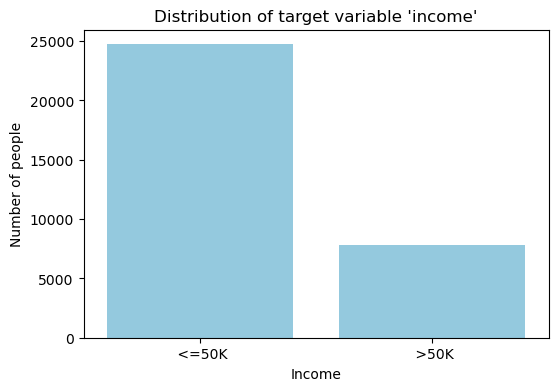

In [33]:
plt.figure(figsize=(6,4))
sns.countplot(x=eda_data['income'], color='skyblue') 
plt.title("Distribution of target variable 'income'")
plt.xlabel("Income")
plt.ylabel("Number of people")
plt.show()


In [34]:
eda_data['income'].value_counts()


income
<=50K    24720
>50K      7841
Name: count, dtype: int64

### 3.3 Distributions of numeric variables

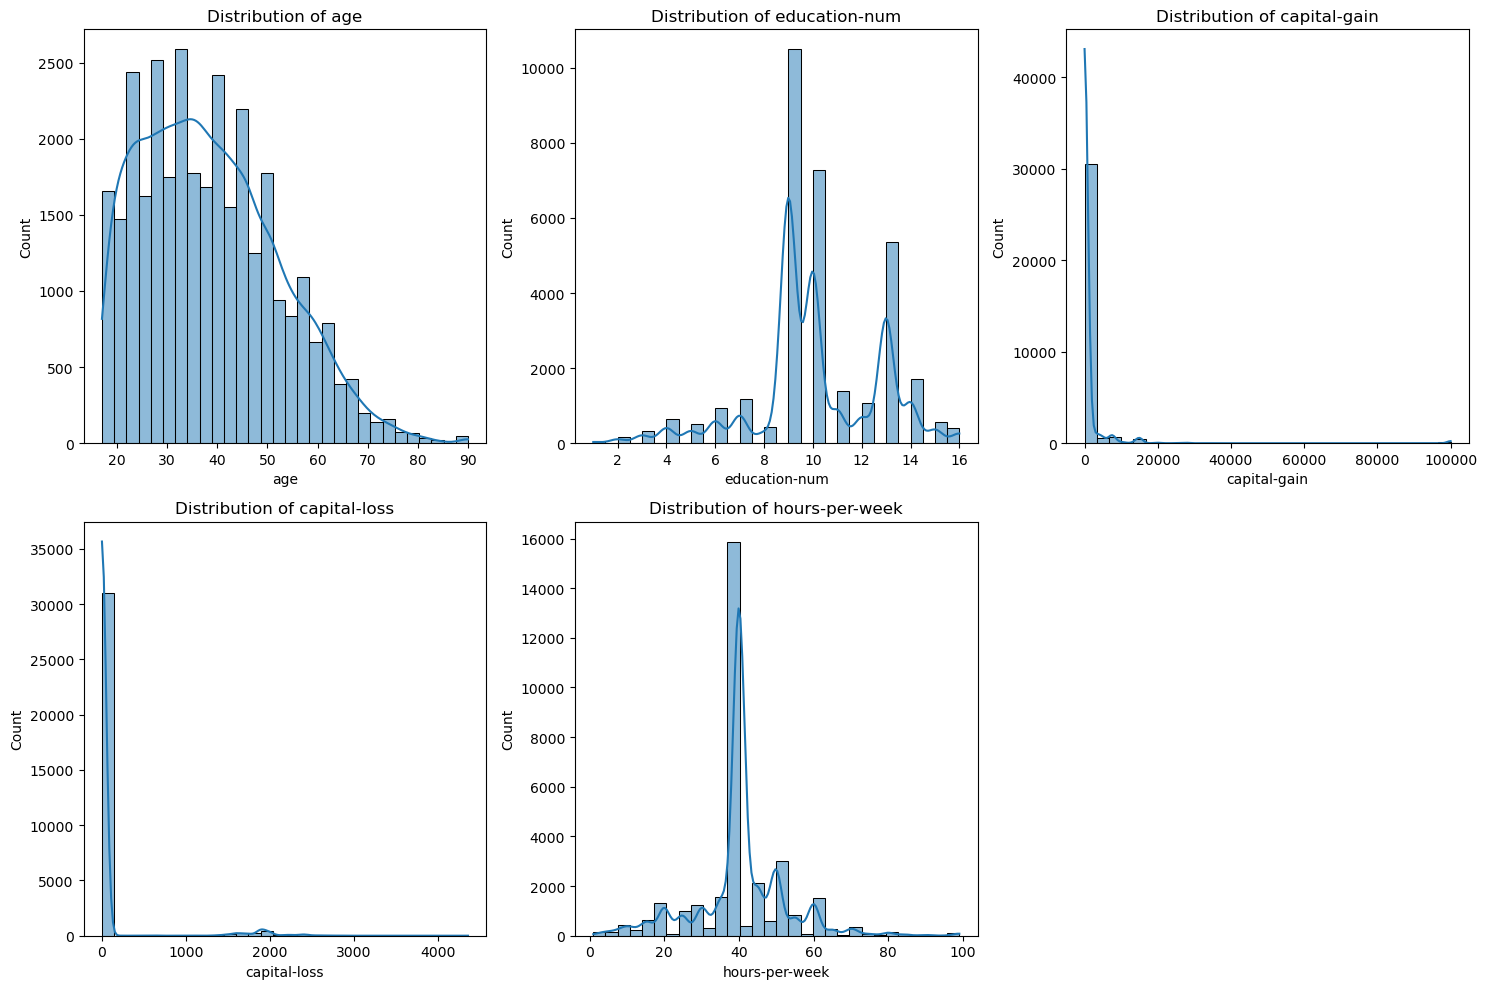

In [35]:
plt.figure(figsize=(15,10))
for i, col in enumerate(num_cols):
    plt.subplot(2,3,i+1)
    sns.histplot(eda_data[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


**Age:** most people are 30–40 — primarily working-age adults.

**Education:** clear peaks at certain levels — people tend to stop at similar milestones (high school, bachelor's).

**Capital gain/loss:** 90% have zero — most people live off wages, not investments.

**Hours per week:** majority works standard 40h, with a notable group at 50+.

### 3.4 Distributions of categorical variables

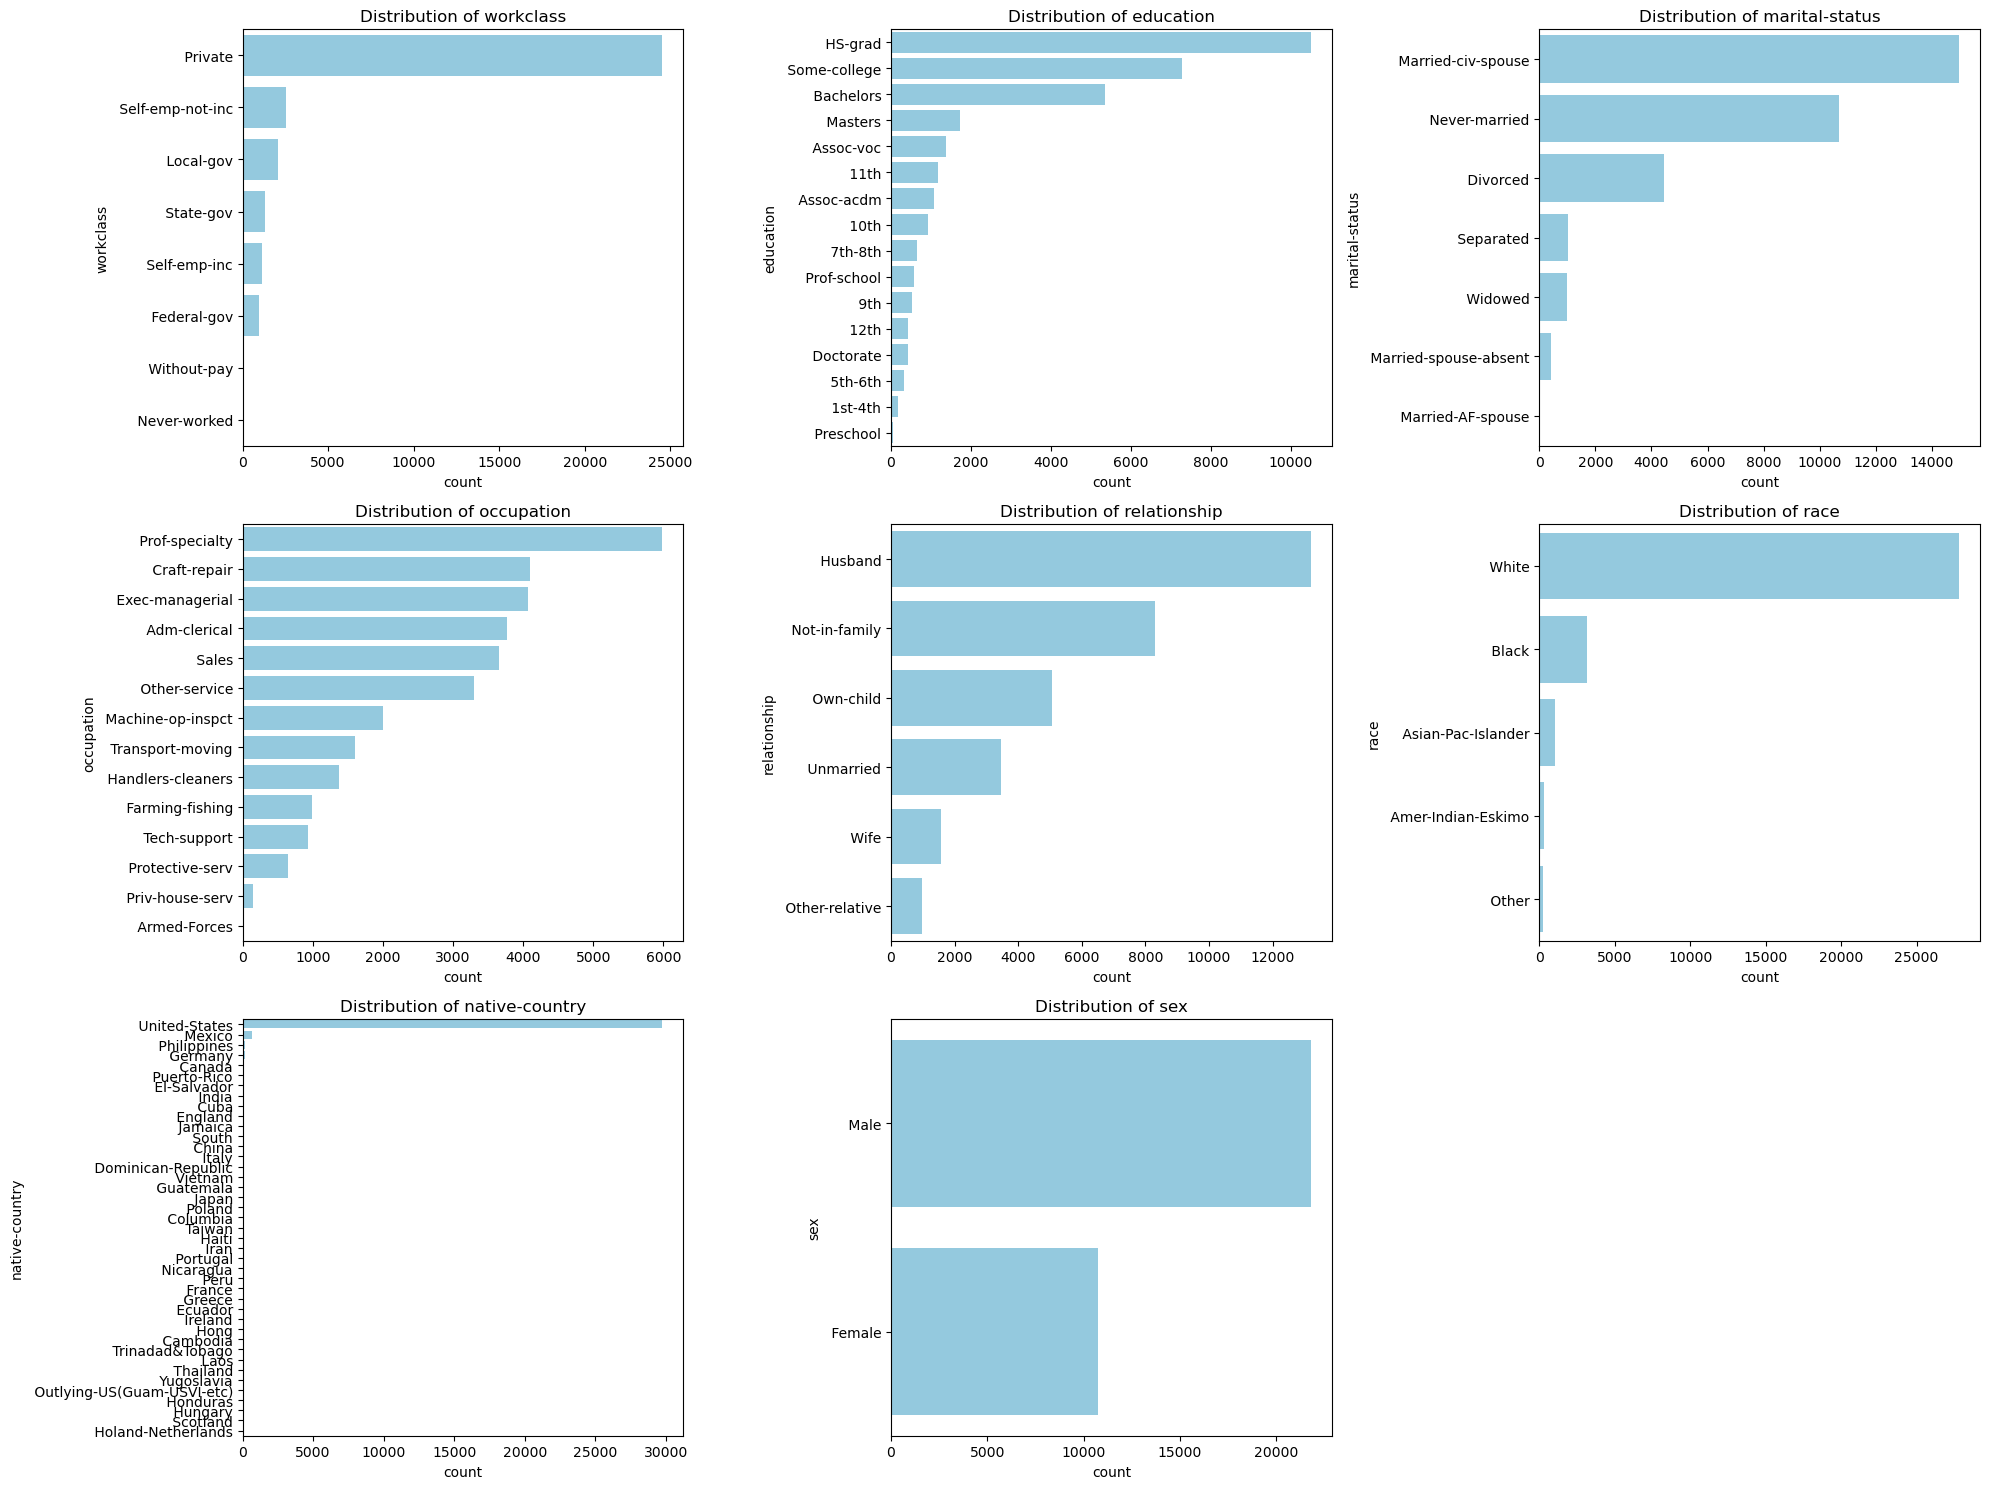

In [36]:
all_cat = cat_cols + ['sex']

plt.figure(figsize=(20,15))

for i, col in enumerate(all_cat):
    plt.subplot(3,3,i+1)
    sns.countplot(y=eda_data[col], order=eda_data[col].value_counts().index, color='skyblue')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

**Work class:** ~two-thirds work in the private sector.

**Education:** most common is high school graduate, then some college, then bachelor's.

**Marital status:** married people dominate, followed by never-married and divorced.

**Race:** reflects US demographics in the 1990s — White majority, Black second largest group.

**Sex:** men make up ~two-thirds, reflecting higher male workforce participation in the 1990s.

### 3.5 Numeric features vs. income (box plots)

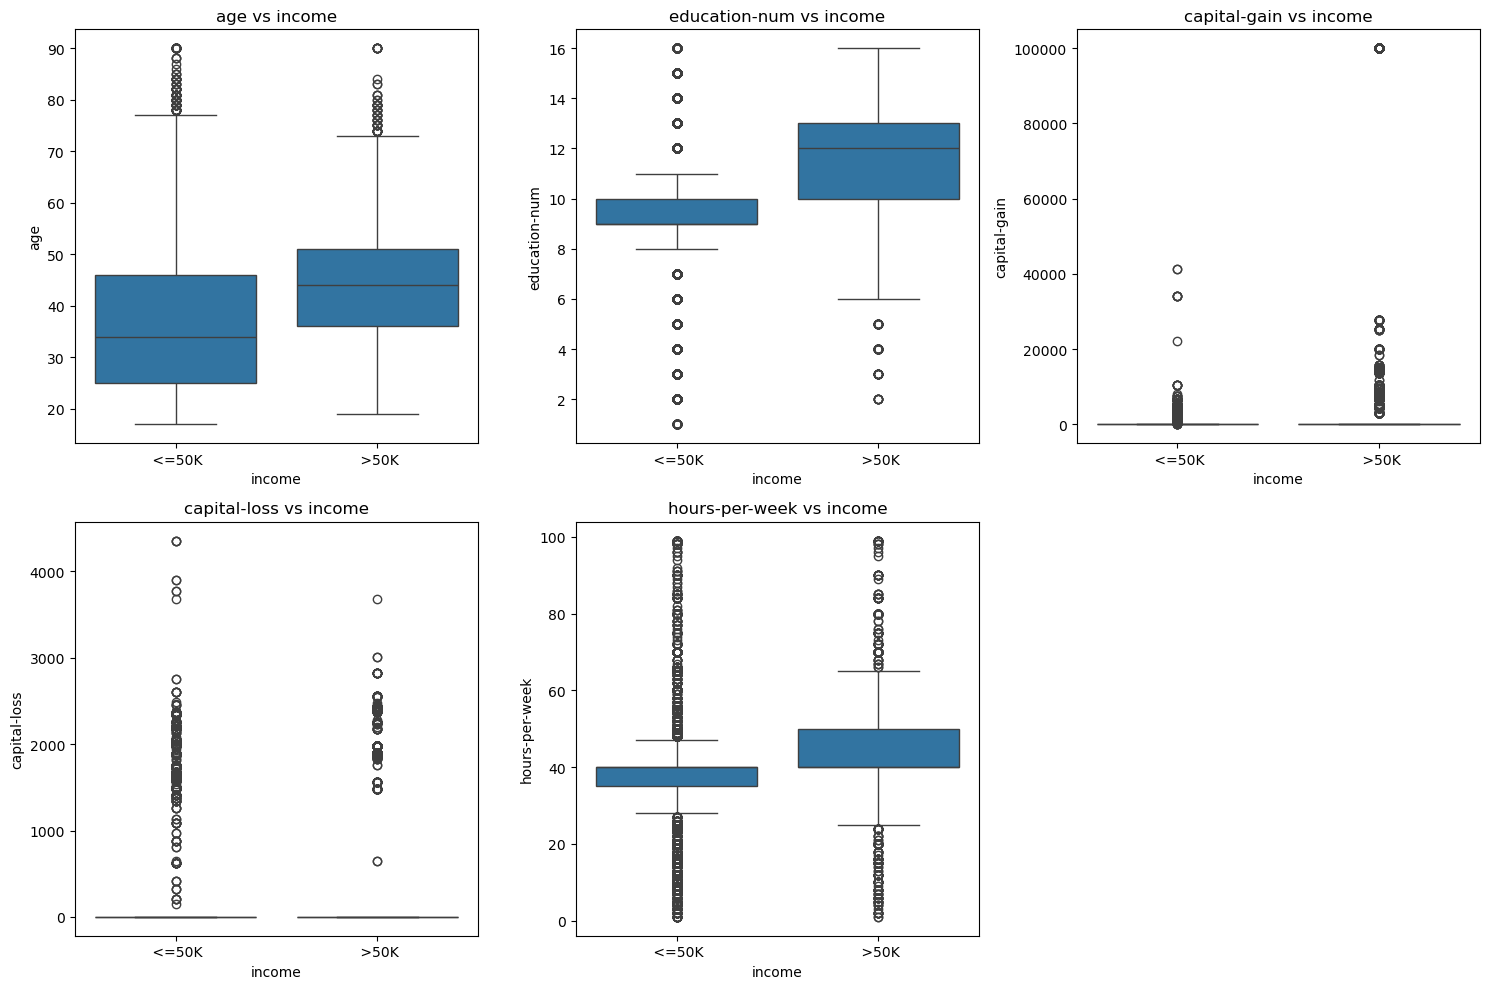

In [37]:
plt.figure(figsize=(15,10))
for i, col in enumerate(num_cols):
    plt.subplot(2,3,i+1)
    sns.boxplot(x='income', y=col, data=eda_data)
    plt.title(f'{col} vs income')
plt.tight_layout()
plt.show()


Key predictors of income:
- **Education** — consistently higher with more years of schooling
- **Age** — older people tend to earn more
- **Capital gain** — having *any* capital income strongly suggests earning >50K
- **Hours per week** — moderate effect

### 3.6 Categorical features vs. income

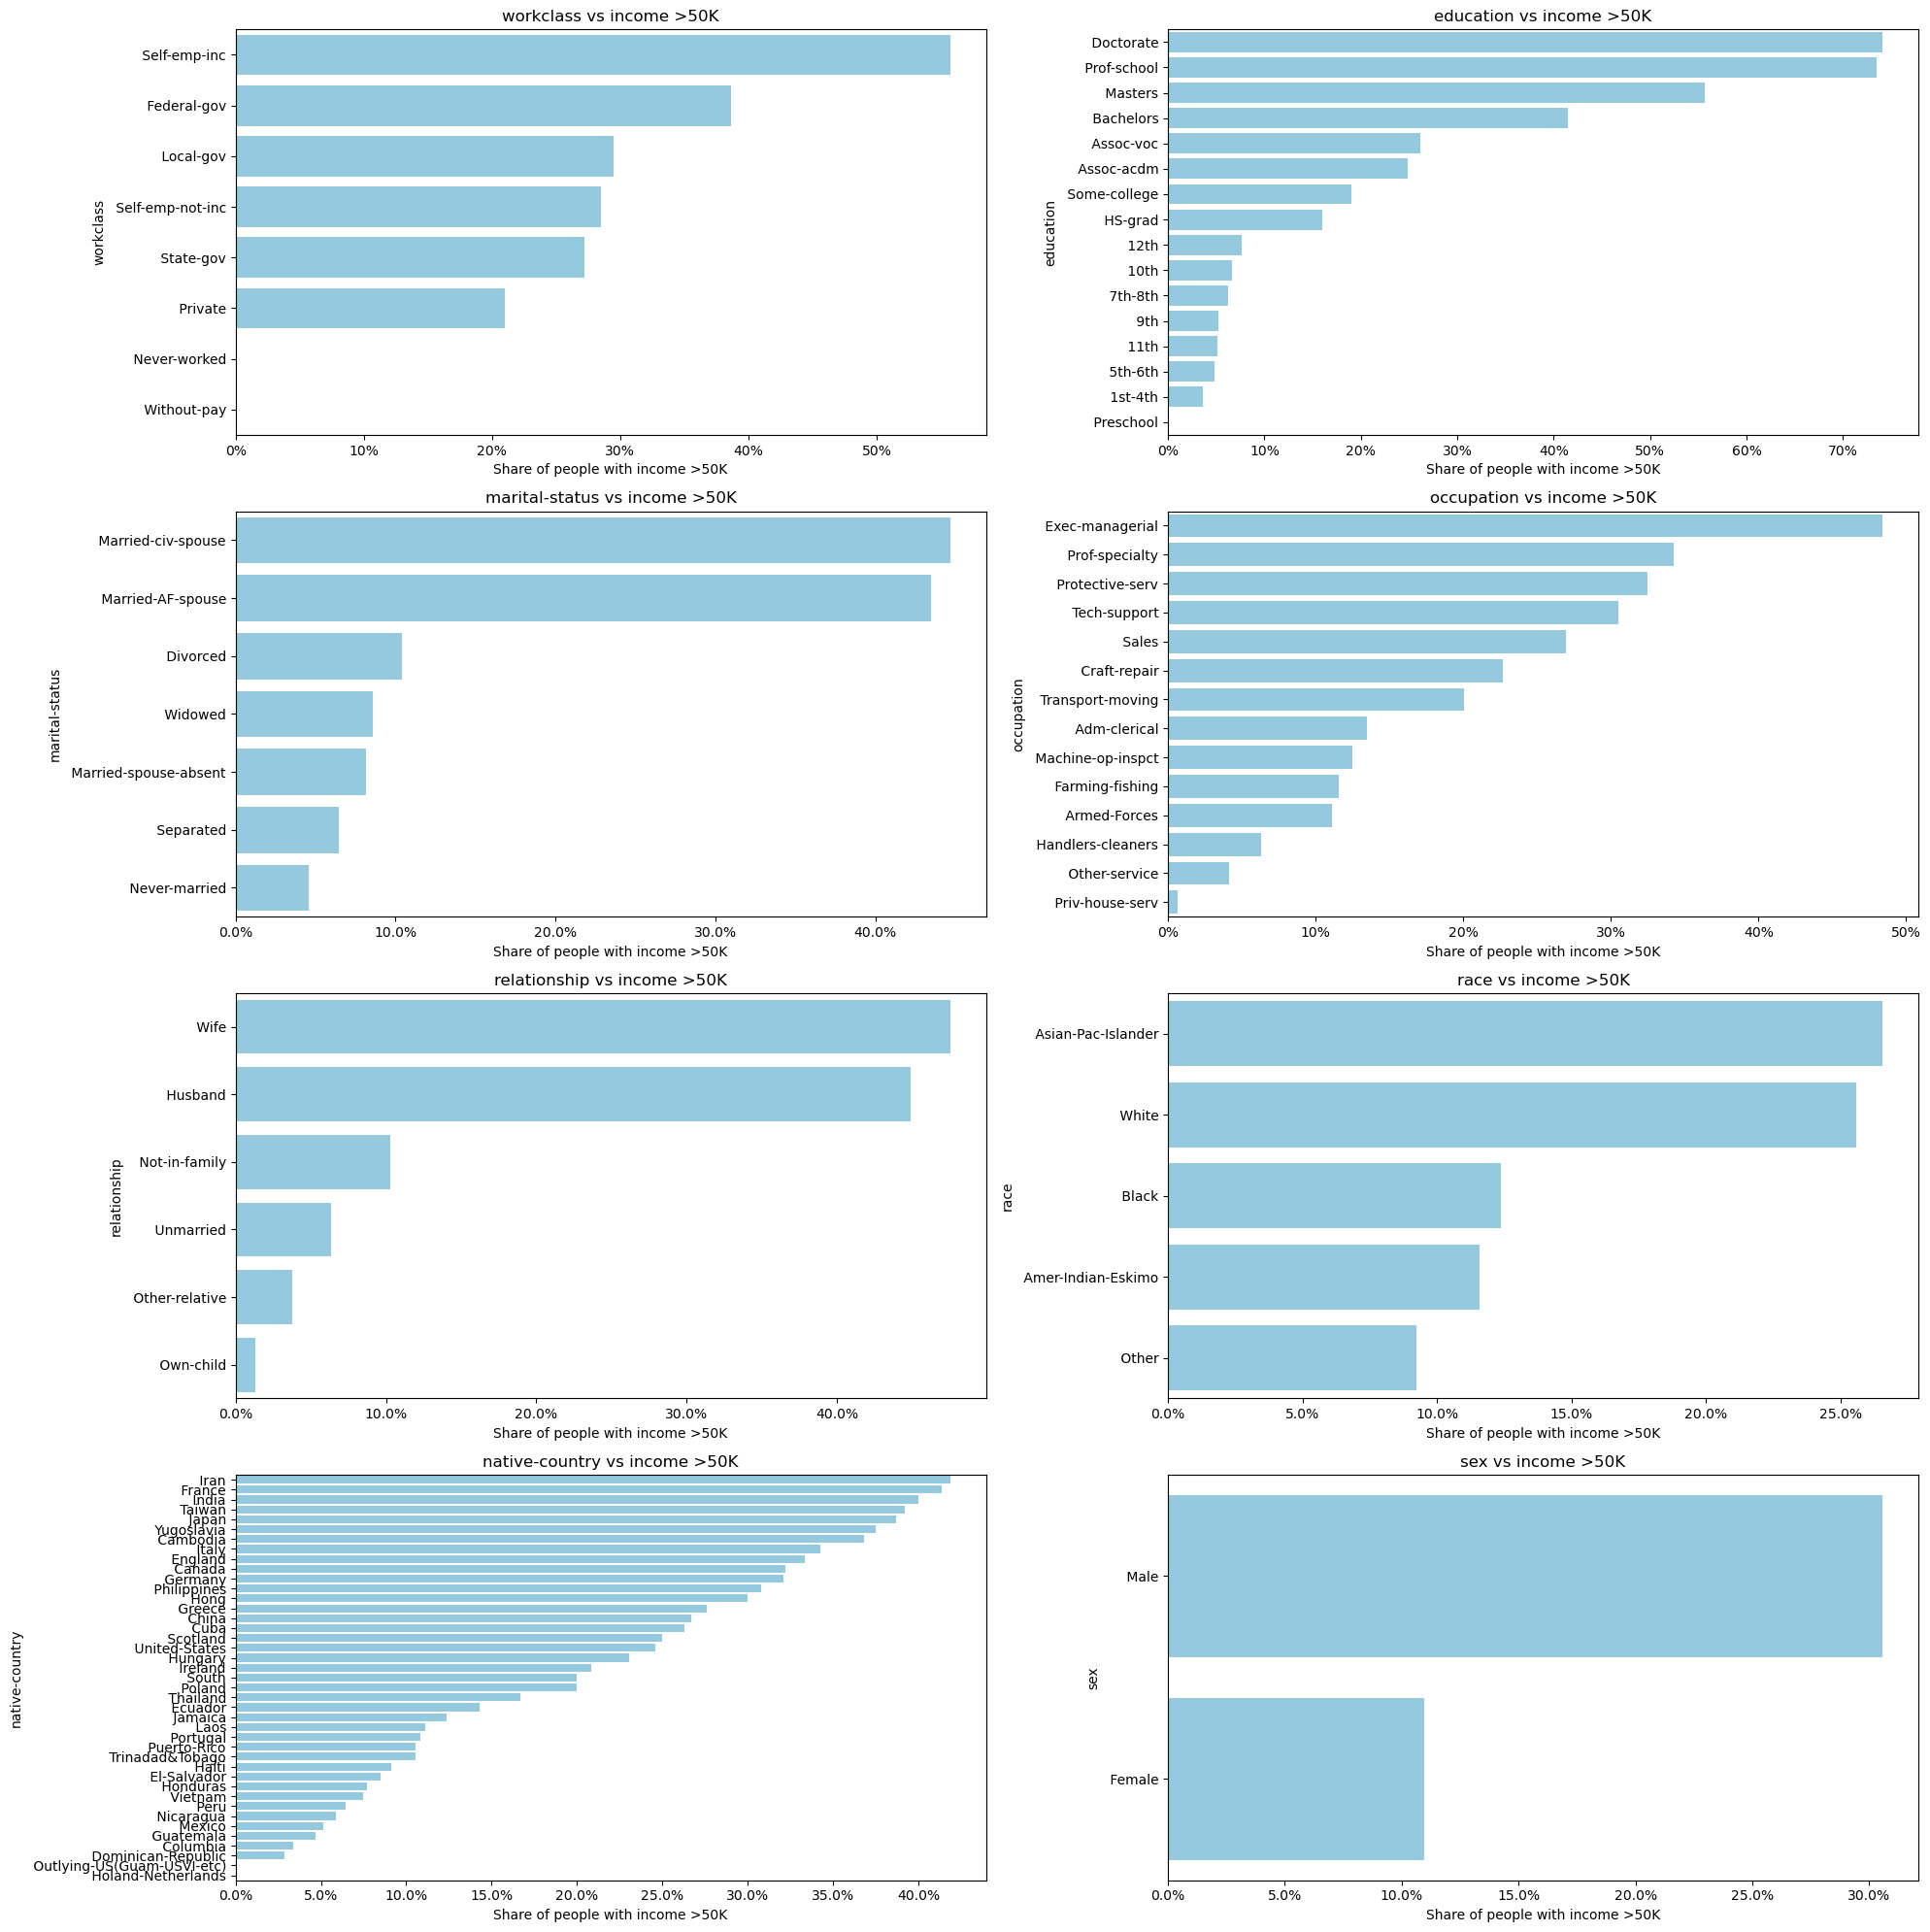

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

eda_data['income'] = eda_data['income'].str.strip()

# all categorical + binary sex
cols_to_check = ['workclass', 'education', 'marital-status', 
                 'occupation', 'relationship', 'race', 'native-country', 'sex']

plt.figure(figsize=(20,20))

for i, col in enumerate(cols_to_check):
    plt.subplot(4,2,i+1)
    
    # proportion of people with income >50K per category
    prop = (eda_data.groupby(col)['income']
            .apply(lambda x: (x=='>50K').mean())
            .sort_values(ascending=False))
    
    # bar plot
    sns.barplot(x=prop.values, y=prop.index, color='skyblue')
    
    # % on x axis
    plt.xlabel('Share of people with income >50K')
    plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    plt.title(f'{col} vs income >50K')

plt.tight_layout()
plt.show()


**Education** is the strongest predictor — over 60% of people with a doctorate earn >50K vs almost 0% with elementary school only.

**Marital status** is a strong signal — 40% of married people earn >50K vs only 5% of singles.

**Gender gap is stark** — men are ~3× more likely to earn >50K (30% vs 10%). This reflects the 1990s labour market.

**Self-employment with incorporation** stands out — ~40% exceed the threshold vs ~20% for regular private employees.

**Occupation** — managers and professionals show ~45% exceeding $50K.

### 3.7 Segmentation — K-Means Clustering

K-Means lets us find natural groups in the data without using the target variable. We cluster on 4 numeric features: age, education, hours per week, and capital gain.

In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = eda_data[['age', 'education-num', 'hours-per-week', 'capital-gain']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

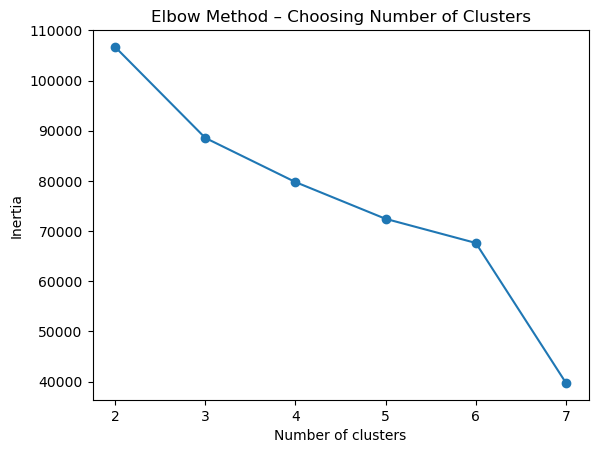

In [40]:
inertia = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 8), inertia, marker='o')
plt.title("Elbow Method – Choosing Number of Clusters")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()


The **elbow method** suggests **3–4 clusters**. We choose **3**:

- **Cluster 1** — young, low education, few hours, no capital gain
- **Cluster 2** — middle-aged, average education, standard hours, some capital gain
- **Cluster 3** — older, well-educated, long hours, notable capital gains

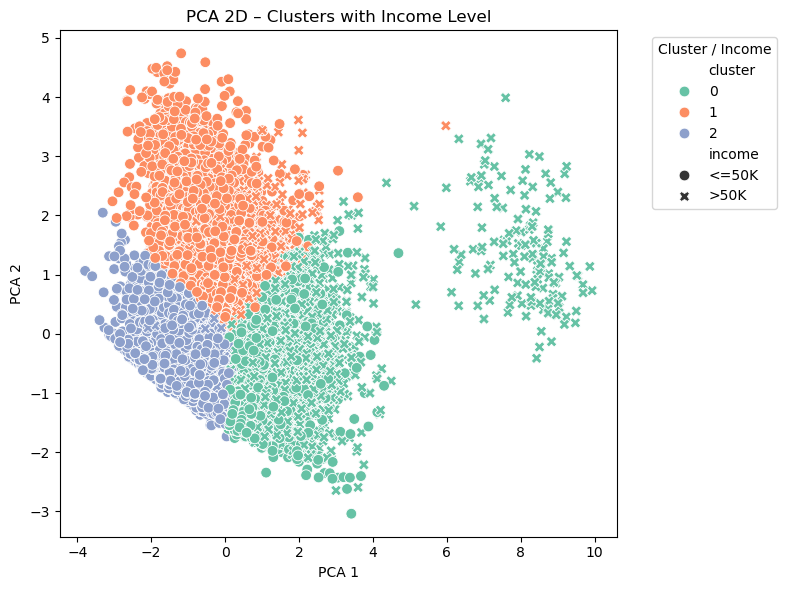

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


features = ['age', 'education-num', 'hours-per-week', 'capital-gain']
X = eda_data[features]


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


kmeans = KMeans(n_clusters=3, random_state=42)
eda_data['cluster'] = kmeans.fit_predict(X_scaled)


pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

eda_data['pca1'] = X_pca[:, 0]
eda_data['pca2'] = X_pca[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=eda_data,
    x='pca1',
    y='pca2',
    hue='cluster',
    style='income',
    palette='Set2',
    s=60
)
plt.title("PCA 2D – Clusters with Income Level")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title='Cluster / Income', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

The PCA plot confirms the clusters are reasonably separated. High earners (>50K, shown as crosses) concentrate in the third cluster — confirming that age, education, and capital gain naturally align with higher income.

---
## Part 4: Model Building and Hyperparameter Tuning

We build **3 classification models** and tune hyperparameters using **GridSearchCV with 3-fold cross-validation**, optimising for **F1-score** (appropriate metric for imbalanced classes).

### Split features and target

In [42]:
from sklearn.model_selection import train_test_split

# X = all features, y = target variable
X_train = train_data.drop('income', axis=1)
y_train = train_data['income']

X_test = test_data.drop('income', axis=1)
y_test = test_data['income']

X_train.shape, X_test.shape

((32561, 97), (16280, 97))

### Model 1 — Logistic Regression (baseline)

A simple, interpretable model that estimates the log-odds of belonging to the high-income class. Serves as our baseline and is useful for understanding which features drive the prediction.

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

log_reg = LogisticRegression(max_iter=1000, solver='lbfgs')

param_grid_log = {
    'C': [0.01, 0.1, 1, 10],        # regularization strength (smaller C = stronger penalty)
    'penalty': ['l2']
}

grid_log = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid_log,
    scoring='f1',           # because classes are imbalanced
    cv=3,
    n_jobs=-1
)

grid_log.fit(X_train, y_train)

print("Best parameters (LogReg):", grid_log.best_params_)
print("Best CV score (F1):", grid_log.best_score_)

Best parameters (LogReg): {'C': 1, 'penalty': 'l2'}
Best CV score (F1): 0.6453717709507613


### Model 2 — Random Forest

An ensemble of decision trees that votes on the final prediction. It handles non-linear relationships and feature interactions well, and is robust to overfitting — a strong upgrade over logistic regression on tabular data like this.

In [44]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [100, 200],      # number of trees
    'max_depth': [None, 10, 20],     # maximum tree depth
    'min_samples_split': [2, 10],    # minimum samples to split a node
    'min_samples_leaf': [1, 4]       # minimum samples at a leaf node
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    scoring='f1',
    cv=3,
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best parameters (RF):", grid_rf.best_params_)
print("Best CV score (F1):", grid_rf.best_score_)

Best parameters (RF): {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Best CV score (F1): 0.6852873791904828


### Model 3 — Histogram Gradient Boosting

Builds shallow decision trees sequentially — each tree corrects the errors of the previous one. This approach is particularly effective at capturing complex, non-linear patterns in tabular data.

In [45]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(random_state=42)

param_grid_hgb = {
    'learning_rate': [0.05, 0.1],
    'max_depth': [None, 6, 10],
    'max_iter': [100, 200]
}

grid_hgb = GridSearchCV(
    estimator=hgb,
    param_grid=param_grid_hgb,
    scoring='f1',
    cv=3,
    n_jobs=-1
)

grid_hgb.fit(X_train, y_train)

print("Best parameters (HGB):", grid_hgb.best_params_)
print("Best CV score (F1):", grid_hgb.best_score_)

Best parameters (HGB): {'learning_rate': 0.1, 'max_depth': 6, 'max_iter': 200}
Best CV score (F1): 0.709817648764667


---
## Part 5: Model Evaluation

### 5.1 Performance on the test set

In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

best_log = grid_log.best_estimator_
best_rf = grid_rf.best_estimator_
best_hgb = grid_hgb.best_estimator_

models = {
    'Logistic Regression': best_log,
    'Random Forest': best_rf,
    'HistGradientBoosting': best_hgb
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results.append([name, acc, prec, rec, f1, auc])

results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC AUC'])
results_df

,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,Logistic Regression,0.845885,0.714332,0.579303,0.639770,0.898191
1,Random Forest,0.860872,0.752960,0.611804,0.675082,0.910977
2,HistGradientBoosting,0.872236,0.776110,0.645346,0.704713,0.926756


The two ensemble methods clearly outperform logistic regression. HistGradientBoosting best captures the complex, non-linear relationships between features and income.

In [47]:
results_df.to_excel("model_results.xlsx", index=False)

### 5.2 ROC Curves

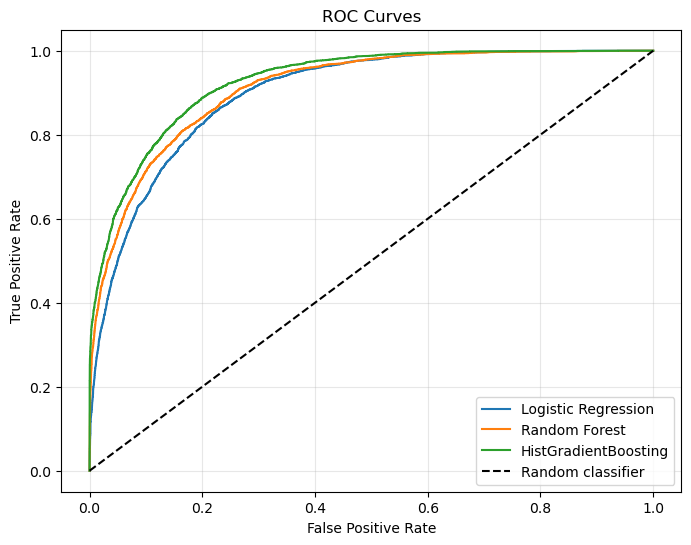

In [48]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


The ROC curve shows the trade-off between TPR and FPR at different decision thresholds. HistGradientBoosting achieves the highest AUC — confirming it as the best model.

### 5.3 Confusion Matrices

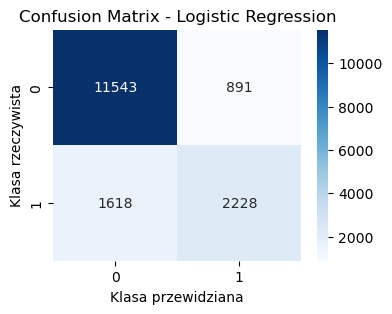

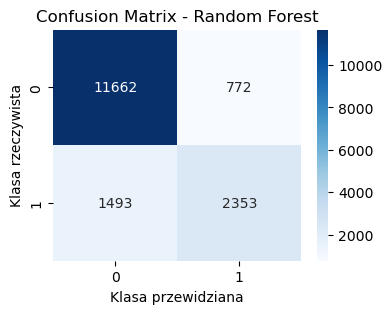

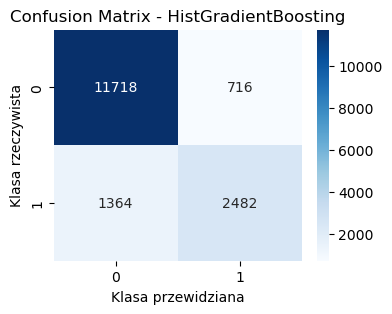

In [49]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Klasa przewidziana')
    plt.ylabel('Klasa rzeczywista')
    plt.show()

Logistic regression produces the most false negatives (FN) — incorrectly classifying high earners as low earners. Random Forest reduces both FP and FN. HistGradientBoosting achieves the lowest error counts on both types, consistent with its leading F1 and ROC-AUC scores.

---
## Summary

This project covered the full ML pipeline on the Adult Income Dataset.

**Key data challenges handled:**
- `"?"` values required manual NaN replacement
- Log transformation applied to `capital-gain`, `capital-loss`, `hours-per-week` for skewed distributions
- One-hot encoding expanded the feature space to 98 columns
- Imbalanced classes required F1 and ROC-AUC over accuracy

**EDA findings:** Education, age, and capital gain are the strongest predictors. Gender and marital status also show clear patterns.

**Model results:**

| Model | Notes |
|---|---|
| Logistic Regression | Baseline; limited by linearity assumption |
| Random Forest | Strong improvement; handles non-linear interactions |
| **HistGradientBoosting** | **Best F1, best ROC-AUC, fewest errors — final model** |

The project demonstrated that model choice matters, but data preparation matters even more.